In [95]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from glcm_lib import manual_vertical_glcm_fn, manual_horizontal_glcm_fn, manual_diagonal_glcm_fn, plot_glcm, maxm_probability, energy, entropy, contrast, homogenity

Text(0, 0.5, 'Y axis')

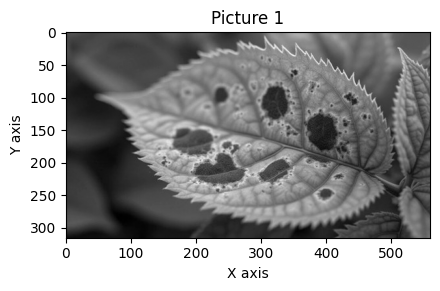

In [96]:
img=cv2.imread("../assets/Picture3.jpg",0)

plt.figure(figsize=(16, 12))
plt.subplot(1, 3, 1)
plt.imshow(img, cmap='gray')
plt.title('Picture 1')
plt.xlabel('X axis')
plt.ylabel('Y axis')

In [97]:
print(img)

[[ 74  75  75 ...  76  76  77]
 [ 73  73  74 ...  76  76  77]
 [ 71  71  71 ...  77  77  78]
 ...
 [ 19  18  18 ... 105 107 109]
 [ 15  15  15 ... 106 108 110]
 [ 14  13  13 ... 106 109 110]]


In [98]:
def glcm_patch(image, center_y, center_x, patch_size=5):
    half = patch_size // 2
    y1 = max(center_y - half, 0)
    y2 = min(center_y + half + 1, image.shape[0])
    x1 = max(center_x - half, 0)
    x2 = min(center_x + half + 1, image.shape[1])
    return image[y1:y2, x1:x2]

In [99]:
img_patch = glcm_patch(img, 2, 2, patch_size=5)

minp,maxp=img_patch.min(),img_patch.max()
lvls=int(maxp-minp+1)
qpatch=(img_patch - minp).astype(np.uint8)

print(img_patch)
print(lvls)
print(qpatch)

[[74 75 75 76 76]
 [73 73 74 75 75]
 [71 71 71 72 73]
 [68 68 69 70 70]
 [68 68 68 69 70]]
9
[[6 7 7 8 8]
 [5 5 6 7 7]
 [3 3 3 4 5]
 [0 0 1 2 2]
 [0 0 0 1 2]]


In [100]:
def manual_vertical_glcm_fn(image, levels=256):
    glcm = np.zeros((levels, levels), dtype=int)
    h, w = image.shape
    for y in range(h - 1): 
        for x in range(w):
            i = image[y, x]
            j = image[y + 1, x]
            glcm[i, j] += 1
    # glcm = glcm / glcm.sum()        
    return glcm

In [101]:
def manual_horizontal_glcm_fn(image, levels=256):
    glcm = np.zeros((levels, levels), dtype=int)
    h, w = image.shape
    for y in range(h): 
        for x in range(w - 1):
            i = image[y, x]
            j = image[y, x + 1]
            glcm[i, j] += 1
    # glcm = glcm / glcm.sum()        
    return glcm

In [102]:
def manual_diagonal_glcm_fn(image, levels=256):
    glcm = np.zeros((levels, levels), dtype=int)
    h, w = image.shape
    for y in range(h - 1): 
        for x in range(w - 1):
            i = image[y, x]
            j = image[y + 1, x + 1]
            glcm[i, j] += 1
    # glcm = glcm / glcm.sum()        
    return glcm

In [103]:
patch_glcm_v = manual_vertical_glcm_fn(qpatch, levels=lvls)
patch_glcm_h = manual_horizontal_glcm_fn(qpatch, levels=lvls)
patch_glcm_d = manual_diagonal_glcm_fn(qpatch, levels=lvls)

In [104]:
print(patch_glcm_v)

[[2 0 0 0 0 0 0 0 0]
 [1 0 0 0 0 0 0 0 0]
 [0 1 1 0 0 0 0 0 0]
 [2 1 0 0 0 0 0 0 0]
 [0 0 1 0 0 0 0 0 0]
 [0 0 1 2 0 0 0 0 0]
 [0 0 0 1 0 1 0 0 0]
 [0 0 0 0 1 2 1 0 0]
 [0 0 0 0 0 0 0 2 0]]


In [105]:
print(patch_glcm_h)

[[3 2 0 0 0 0 0 0 0]
 [0 0 2 0 0 0 0 0 0]
 [0 0 1 0 0 0 0 0 0]
 [0 0 0 2 1 0 0 0 0]
 [0 0 0 0 0 1 0 0 0]
 [0 0 0 0 0 1 1 0 0]
 [0 0 0 0 0 0 0 2 0]
 [0 0 0 0 0 0 0 2 1]
 [0 0 0 0 0 0 0 0 1]]


In [106]:
print(patch_glcm_d)

[[2 0 0 0 0 0 0 0 0]
 [0 1 0 0 0 0 0 0 0]
 [0 0 1 0 0 0 0 0 0]
 [1 1 1 0 0 0 0 0 0]
 [0 0 1 0 0 0 0 0 0]
 [0 0 0 2 0 0 0 0 0]
 [0 0 0 0 1 1 0 0 0]
 [0 0 0 0 0 1 1 1 0]
 [0 0 0 0 0 0 0 1 0]]


In [107]:
def plot_glcm(img, glcm1, glcm2, glcm3,title0, title1, title2, title3):
    plt.figure(figsize=(20, 16))

    ax0=plt.subplot(1, 4, 1)
    im0 = ax0.imshow(img, cmap='gray')
    ax0.set_title(title0)
    ax0.set_xlabel('X axis')
    ax0.set_ylabel('Y axis')

    ax1 = plt.subplot(1, 4, 2)
    im1 = ax1.imshow(glcm1, cmap='hot', interpolation='nearest')
    ax1.set_title(title1)
    ax1.set_xlabel('Gray Level j')
    ax1.set_ylabel('Gray Level i')
    plt.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04, label='Probability')

    ax2 = plt.subplot(1, 4, 3)
    im2 = ax2.imshow(glcm2, cmap='hot', interpolation='nearest')
    ax2.set_title(title2)
    ax2.set_xlabel('Gray Level j')
    ax2.set_ylabel('Gray Level i')
    plt.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04, label='Probability')

    ax3 = plt.subplot(1, 4, 4)
    im3 = ax3.imshow(glcm3, cmap='hot', interpolation='nearest')
    ax3.set_title(title3)
    ax3.set_xlabel('Gray Level j')
    ax3.set_ylabel('Gray Level i')
    plt.colorbar(im3, ax=ax3, fraction=0.046, pad=0.04, label='Probability')

    plt.tight_layout()
    plt.show()

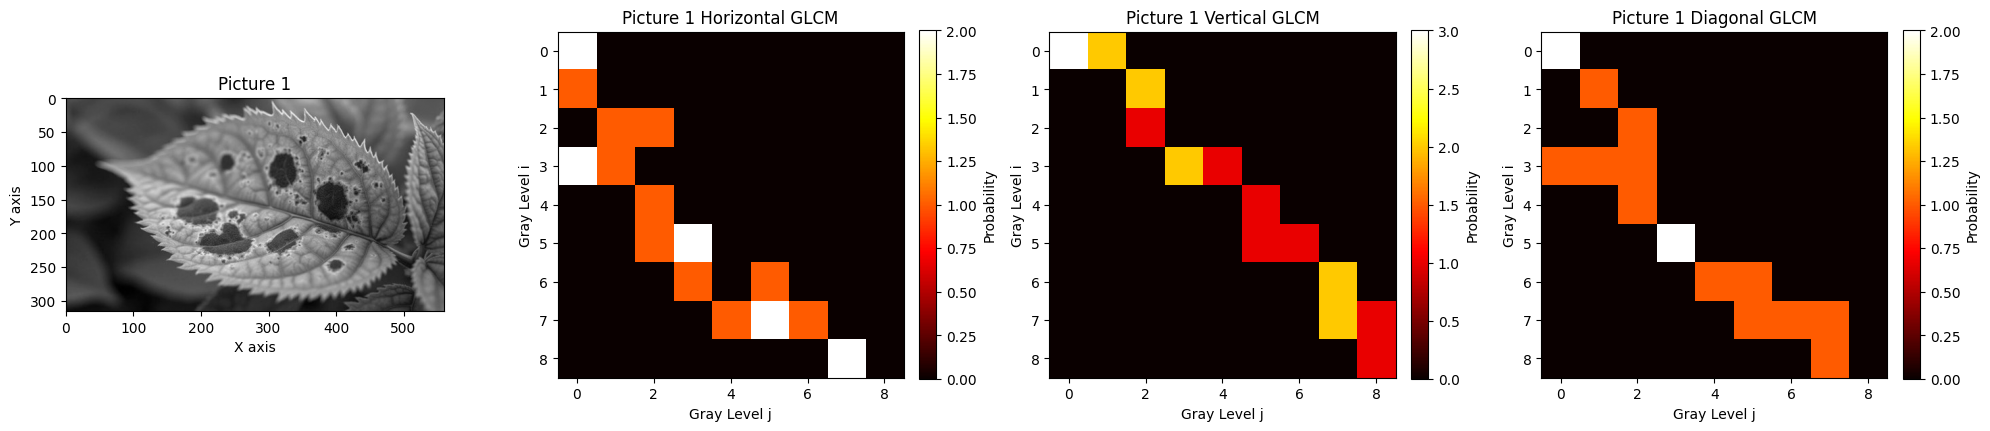

In [108]:
plot_glcm(img, patch_glcm_v, patch_glcm_h, patch_glcm_d,'Picture 1', 'Picture 1 Horizontal GLCM', 'Picture 1 Vertical GLCM', 'Picture 1 Diagonal GLCM')